This notebook is used in a Kaggle competition hosted by Stanford. More information about the competition can be found [here](https://www.kaggle.com/competitions/stanford-rna-3d-folding/overview).

In [2]:
import pandas as pd
import numpy as np

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

## Exploratory data analysis

In [24]:
train_sequence_df = pd.read_csv('../dataset/train_sequences.csv')
test_sequence_df = pd.read_csv('../dataset/test_sequences.csv')
validation_sequence_df = pd.read_csv('../dataset/validation_sequences.csv')

train_labels_df = pd.read_csv('../dataset/train_labels.csv')
validation_labels_df = pd.read_csv('../dataset/validation_labels.csv')


print(f'train_sequence_df:\n{train_sequence_df.head()}\n\ntest_sequence_df:\n{test_sequence_df.head()}')

train_sequence_df:
  target_id                            sequence temporal_cutoff  \
0    1SCL_A       GGGUGCUCAGUACGAGAGGAACCGCACCC      1995-01-26   
1    1RNK_A  GGCGCAGUGGGCUAGCGCCACUCAAAAGGCCCAU      1995-02-27   
2    1RHT_A            GGGACUGACGAUCACGCAGUCUAU      1995-06-03   
3    1HLX_A                GGGAUAACUUCGGUUGUCCC      1995-09-15   
4    1HMH_E  GGCGACCCUGAUGAGGCCGAAAGGCCGAAACCGU      1995-12-07   

                                         description  \
0               THE SARCIN-RICIN LOOP, A MODULAR RNA   
1  THE STRUCTURE OF AN RNA PSEUDOKNOT THAT CAUSES...   
2  24-MER RNA HAIRPIN COAT PROTEIN BINDING SITE F...   
3  P1 HELIX NUCLEIC ACIDS (DNA/RNA) RIBONUCLEIC ACID   
4  THREE-DIMENSIONAL STRUCTURE OF A HAMMERHEAD RI...   

                                       all_sequences  
0  >1SCL_1|Chain A|RNA SARCIN-RICIN LOOP|Rattus n...  
1  >1RNK_1|Chain A|RNA PSEUDOKNOT|null\nGGCGCAGUG...  
2  >1RHT_1|Chain A|RNA (5'-R(P*GP*GP*GP*AP*CP*UP*...  
3  >1HLX_1|Chain A|RN

In [25]:
train_sequence_df = train_sequence_df.drop(columns=['temporal_cutoff', 'description'], axis=1)
print( train_sequence_df )

    target_id                                           sequence  \
0      1SCL_A                      GGGUGCUCAGUACGAGAGGAACCGCACCC   
1      1RNK_A                 GGCGCAGUGGGCUAGCGCCACUCAAAAGGCCCAU   
2      1RHT_A                           GGGACUGACGAUCACGCAGUCUAU   
3      1HLX_A                               GGGAUAACUUCGGUUGUCCC   
4      1HMH_E                 GGCGACCCUGAUGAGGCCGAAAGGCCGAAACCGU   
..        ...                                                ...   
839   8T3E_EC  AAACUCCAUGUAUUGGUUACCCAUCUGCAUCGAAAACUCUCCGAAC...   
840   8T3F_EC  AAACUCCAUGUAUUGGUUACCCAUCUGCAUCGAAAACUCUCCGAAC...   
841    8XCC_B  GUGCUGCUGUCUCCCAGACGGGAGGCAGAACUGCACCUUCCAUCAG...   
842    8Z1G_T  GGUAAAAUGGCUGAGUGAAGCAUUGGACUGUAAAUCUAAAGACAGG...   
843    8Z1F_T  GGUAAAAUGGCUGAGUGAAGCAUUGGACUGUAAAUCUAAAGACAGG...   

                                         all_sequences  
0    >1SCL_1|Chain A|RNA SARCIN-RICIN LOOP|Rattus n...  
1    >1RNK_1|Chain A|RNA PSEUDOKNOT|null\nGGCGCAGUG...  
2    >1RHT_1

In [26]:
test_sequence_df = test_sequence_df.drop( columns=['temporal_cutoff', 'description'], axis=1 )
print(test_sequence_df)

   target_id                                           sequence  \
0      R1107  GGGGGCCACAGCAGAAGCGUUCACGUCGCAGCCCCUGUCAGCCAUU...   
1      R1108  GGGGGCCACAGCAGAAGCGUUCACGUCGCGGCCCCUGUCAGCCAUU...   
2      R1116  CGCCCGGAUAGCUCAGUCGGUAGAGCAGCGGCUAAAACAGCUCUGG...   
3    R1117v2                     UUGGGUUCCCUCACCCCAAUCAUAAAAAGG   
4      R1126  GGAAUCUCGCCCGAUGUUCGCAUCGGGAUUUGCAGGUCCAUGGAUU...   
5      R1128  GGAAUAUCGUCAUGGUGAUUCGUCACCAUGAGGCUAGAUCUCAUAU...   
6      R1136  GGAUACGUCUACGCUCAGUGACGGACUCUCUUCGGAGAGUCUGACA...   
7      R1138  GGGAGAGUACUAUUCAGAUGCAGACCGCAAGUUCAGAGCGGUUUGC...   
8      R1149  GGACACGAGUAACUCGUCUAUCUUCUGCAGGCUGCUUACGGUUUCG...   
9      R1156  GGAGCAUCGUGUCUCAAGUGCUUCACGGUCACAAUAUACCGUUUCG...   
10     R1189  GCGUACAGGGAACACGCAACCCCGAAGGAUCGGGGAAGGGACGUCG...   
11     R1190  GCGUACAGGGAACACGCAACCCCGAAGGAUCGGGGAAGGGACGUCG...   

                                        all_sequences  
0   >7QR4_1|Chain A|U1 small nuclear ribonucleopro...  
1   >7QR3_1|Chai

In [ ]:
rna_nucleo_encoding = {     # encoding RNA nucleotides for model to understand
    'A': 0,
    'C': 1,
    'G': 2,
    'U': 3
}

In [13]:
print(f'\n\nvalidation_sequence_df:\n{validation_sequence_df.head()}')



validation_sequence_df:
  target_id                                           sequence  \
0     R1107  GGGGGCCACAGCAGAAGCGUUCACGUCGCAGCCCCUGUCAGCCAUU...   
1     R1108  GGGGGCCACAGCAGAAGCGUUCACGUCGCGGCCCCUGUCAGCCAUU...   
2     R1116  CGCCCGGAUAGCUCAGUCGGUAGAGCAGCGGCUAAAACAGCUCUGG...   
3   R1117v2                     UUGGGUUCCCUCACCCCAAUCAUAAAAAGG   
4     R1126  GGAAUCUCGCCCGAUGUUCGCAUCGGGAUUUGCAGGUCCAUGGAUU...   

  temporal_cutoff                                        description  \
0      2022-05-28  CPEB3 ribozyme\nHuman\nhuman CPEB3 HDV-like ri...   
1      2022-05-27  CPEB3 ribozyme\nChimpanzee\nChimpanzee CPEB3 H...   
2      2022-06-04  Cloverleaf RNA\nPoliovirus\nCrystal Structure ...   
3      2022-06-03  PreQ1 class I type III riboswitch\nK. pneumoni...   
4      2022-06-11  Traptamer\nSynthetic\nAdditional Information: ...   

                                       all_sequences  
0  >7QR4_1|Chain A|U1 small nuclear ribonucleopro...  
1  >7QR3_1|Chains A, B|U1 small nu

### Visualizing 3D structures for first 10 RNA sequences

Example:

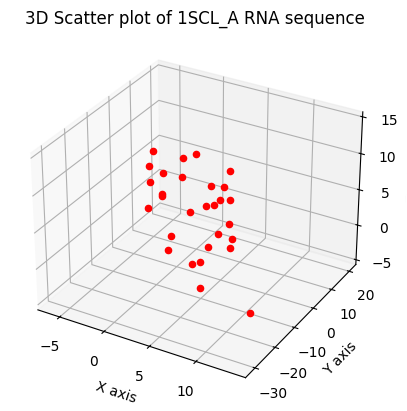

In [32]:
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

for i in range(29):
    ax.scatter(train_labels_df['x_1'][i], train_labels_df['y_1'][i], train_labels_df['z_1'][i], c='r', marker='o')


ax.set_title('3D Scatter plot of 1SCL_A RNA sequence')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

## Building a model

In [17]:
RNAClassifier = keras.Sequential()

2025-03-24 15:13:56.745160: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-24 15:13:56.834564: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Predictions

## Results